# Heart Disease EDA
This notebook explores the Heart Disease dataset, which contains various features related to patients' health and lifestyle. The goal is to perform exploratory data analysis (EDA) to uncover insights and patterns that may be associated with heart disease.

## Clinical Data Dictionary

- **id**: Unique patient identifier (non-clinical; should be dropped for modeling).

- **Age**: Age in years. Cardiovascular risk increases with age due to progressive arterial stiffening and atherosclerosis.

- **Sex**: Biological sex (1 = male, 0 = female). Males generally have higher early risk of coronary artery disease.

- **Chest pain type (cp)**:
  - 1 = Typical angina (classic cardiac chest pain, high likelihood of coronary artery disease)
  - 2 = Atypical angina (some cardiac features, moderate risk)
  - 3 = Non-anginal pain (usually non-cardiac origin)
  - 4 = Asymptomatic (no chest pain despite possible ischemia; clinically high-risk silent disease group)

- **BP (Resting Blood Pressure)**: Resting systolic blood pressure in mm Hg on hospital admission. Hypertension is a major risk factor for coronary artery disease.

- **Cholesterol**: Serum cholesterol level (mg/dL). Elevated cholesterol contributes to plaque buildup and arterial narrowing (atherosclerosis).

- **FBS over 120 (fbs)**: Fasting blood sugar > 120 mg/dL (1 = true, 0 = false). Indicates possible diabetes or impaired glucose metabolism, both strong cardiovascular risk factors.

- **EKG results (restecg)**:
  - 0 = Normal ECG
  - 1 = ST-T wave abnormalities (possible ischemia or electrical instability)
  - 2 = Left ventricular hypertrophy (heart muscle thickening, often due to chronic hypertension)

- **Max HR (thalach)**: Maximum heart rate achieved during exercise stress test. Lower-than-expected values may indicate cardiac dysfunction or poor exercise tolerance.

- **Exercise angina (exang)**: Exercise-induced chest pain (1 = yes, 0 = no). Suggests myocardial ischemia during increased oxygen demand.

- **ST depression (oldpeak)**: ST segment depression during exercise relative to rest. Higher values indicate more severe myocardial ischemia.

- **Slope of ST (slope)**:
  - 1 = Upsloping (generally lower ischemic risk)
  - 2 = Flat (moderate concern for ischemia)
  - 3 = Downsloping (strong indicator of significant coronary artery disease)

- **Number of vessels fluro (ca)**: Number of major coronary vessels (0–3) visible via fluoroscopy. Higher values indicate more extensive coronary artery blockage.

- **Thallium (thal)**:
  - 3 = Normal myocardial perfusion
  - 6 = Fixed defect (permanent damage, prior infarction/scar tissue)
  - 7 = Reversible defect (stress-induced ischemia; clinically very predictive of CAD)

- **Heart Disease (target)**: Presence or absence of clinically significant coronary artery disease (typically defined as >50% narrowing in a major coronary artery).

**Note**: This dataset is a synthetically expanded version of the original Heart Disease dataset, scaled to 630,000 observations to simulate a large-scale clinical dataset.

## 1. Imports

In [2]:
# Standard Data Science Libraries
import numpy as np
import pandas as pd

# Utilities Libraries
from pathlib import Path
import joblib

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Libraries
from scipy import stats
from statsmodels.stats.multitest import multipletests

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Artifact directories
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / 'artifacts').exists() else NOTEBOOK_DIR.parent
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
PLOTS_DIR = ARTIFACTS_DIR / 'plots'
MODELS_DIR = ARTIFACTS_DIR / 'models'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Auto-save each displayed matplotlib figure
PLOT_PREFIX = '01_exploratory_analysis'
_plot_counter = 0
_original_show = plt.show

def show_and_save(*args, **kwargs):
    global _plot_counter
    fig = plt.gcf()
    if fig.get_axes():
        _plot_counter += 1
        plot_path = PLOTS_DIR / f"{PLOT_PREFIX}_plot_{_plot_counter:02d}.png"
        fig.savefig(plot_path, dpi=300, bbox_inches='tight')
    return _original_show(*args, **kwargs)

plt.show = show_and_save
print(f"Plots will be saved to: {PLOTS_DIR}")
print(f"Models will be saved to: {MODELS_DIR}")

Plots will be saved to: c:\Users\biell\Documents\projects\potfolio\Predicting-Heart-Disease\artifacts\plots
Models will be saved to: c:\Users\biell\Documents\projects\potfolio\Predicting-Heart-Disease\artifacts\models


## 2. Loading data and assessing basic properties 

In [3]:
# Load the dataset
heart_data = pd.read_csv('./data/heart_disease.csv')

# Display the first few rows of the dataset
heart_data.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [4]:
# Display the last few rows of the dataset
heart_data.tail()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
629995,629995,56,0,1,110,226,0,0,132,0,0.0,1,0,7,Absence
629996,629996,54,1,4,128,249,1,2,150,0,0.0,2,0,3,Absence
629997,629997,67,1,4,130,275,0,0,149,0,0.0,1,2,7,Presence
629998,629998,52,1,4,140,199,0,2,157,0,0.0,1,0,6,Presence
629999,629999,51,0,2,130,199,0,0,168,0,0.0,1,0,3,Absence


In [5]:
# Display the shape of the dataset
df_shape = heart_data.shape
print(f"The dataset contains {df_shape[0]} rows and {df_shape[1]} columns.")

The dataset contains 630000 rows and 15 columns.


### 💡 Insight:
- This means our data has **13 features** (excluding "id" and our target "Heart Disease") and **630000 entries**.

In [6]:
# Display column names and data types
print("\nColumn Names and Data Types:")
print(heart_data.dtypes)


Column Names and Data Types:
id                           int64
Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease               object
dtype: object


In [7]:
# Display count of unique values in each column
print("\nUnique Values in Each Column:")
print(heart_data.nunique())


Unique Values in Each Column:
id                         630000
Age                            42
Sex                             2
Chest pain type                 4
BP                             66
Cholesterol                   150
FBS over 120                    2
EKG results                     3
Max HR                         93
Exercise angina                 2
ST depression                  66
Slope of ST                     3
Number of vessels fluro         4
Thallium                        3
Heart Disease                   2
dtype: int64


### 💡 Insight:
- Some features labeled as numeric have very few unique values, suggesting they are actually categorical.
- After reviewing the feature definitions, this hypothesis is confirmed.

## 3. Transform columns

In [8]:
# Classify columns into numerical and categorical
categorical_features = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 
                       'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 
                       'Thallium', 'Heart Disease']

numerical_features = [col for col in heart_data.columns if col not in categorical_features and col != 'id']

In [9]:
# Fixing incorrect data types for categorical features
for col in categorical_features:
    heart_data[col] = heart_data[col].astype('category')

# Remove target variable from categorical features list
categorical_features.remove('Heart Disease')

In [10]:
# Display adjusted column names and data types
print("\nAdjusted Column Names and Data Types:")
print(heart_data.dtypes)


Adjusted Column Names and Data Types:
id                            int64
Age                           int64
Sex                        category
Chest pain type            category
BP                            int64
Cholesterol                   int64
FBS over 120               category
EKG results                category
Max HR                        int64
Exercise angina            category
ST depression               float64
Slope of ST                category
Number of vessels fluro    category
Thallium                   category
Heart Disease              category
dtype: object


In [11]:
# Transform categories to more descriptive labels
transformations = {
    'Sex': {1: 'male', 0: 'female'},
    'FBS over 120': {1: 'true', 0: 'false'},
    'Exercise angina': {1: 'yes', 0: 'no'}
}

for feature, mapping in transformations.items():
    heart_data[feature] = heart_data[feature].map(mapping)
    heart_data[feature] = heart_data[feature].astype('category')

In [12]:
# Display the first few rows of the transformed dataset
heart_data[['Sex', 'FBS over 120', 'Exercise angina']].head()

,Sex,FBS over 120,Exercise angina
0,male,false,yes
1,male,false,no
2,female,false,no
3,female,false,no
4,male,false,yes


In [13]:
# Save the cleaned dataset for future use
heart_data.to_csv('./data/heart_disease_cleaned.csv', index=False)

## 4. Assessing data quality

In [14]:
# Count of missing values in each column
missing_values = heart_data.isnull().sum()
print("\nMissing Values in Each Column:")
print(missing_values)


Missing Values in Each Column:
id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64


In [15]:
# Count of duplicate rows
duplicate_count = heart_data.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")


Number of duplicate rows: 0


In [16]:
# Evaluate ranges of numerical features
print("\nRanges of Numerical Features:")
for feature in numerical_features:
    min_value = heart_data[feature].min()
    max_value = heart_data[feature].max()
    print(f"{feature}: Min = {min_value}, Max = {max_value}")


Ranges of Numerical Features:
Age: Min = 29, Max = 77
BP: Min = 94, Max = 200
Cholesterol: Min = 126, Max = 564
Max HR: Min = 71, Max = 202
ST depression: Min = 0.0, Max = 6.2


### 💡 Insight:
- Our data appears clean: no missing values or duplicate rows were detected.
- Clinical variables were inspected for unrealistic physiological values (e.g., negative BP, implausible cholesterol levels), and all ranges were within medically plausible limits.

## 5. Evaluating descriptive statistics

In [17]:
# Display summary statistics
print("\nSummary Statistics for Numerical Features:")
heart_data.describe()


Summary Statistics for Numerical Features:


,id,Age,BP,Cholesterol,Max HR,ST depression
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,54.136706,130.497433,245.011814,152.816763,0.716028
std,181865.479132,8.256301,14.975802,33.681581,19.112927,0.948472
min,0.000000,29.000000,94.000000,126.000000,71.000000,0.000000
25%,157499.750000,48.000000,120.000000,223.000000,142.000000,0.000000
50%,314999.500000,54.000000,130.000000,243.000000,157.000000,0.100000
75%,472499.250000,60.000000,140.000000,269.000000,166.000000,1.400000
max,629999.000000,77.000000,200.000000,564.000000,202.000000,6.200000


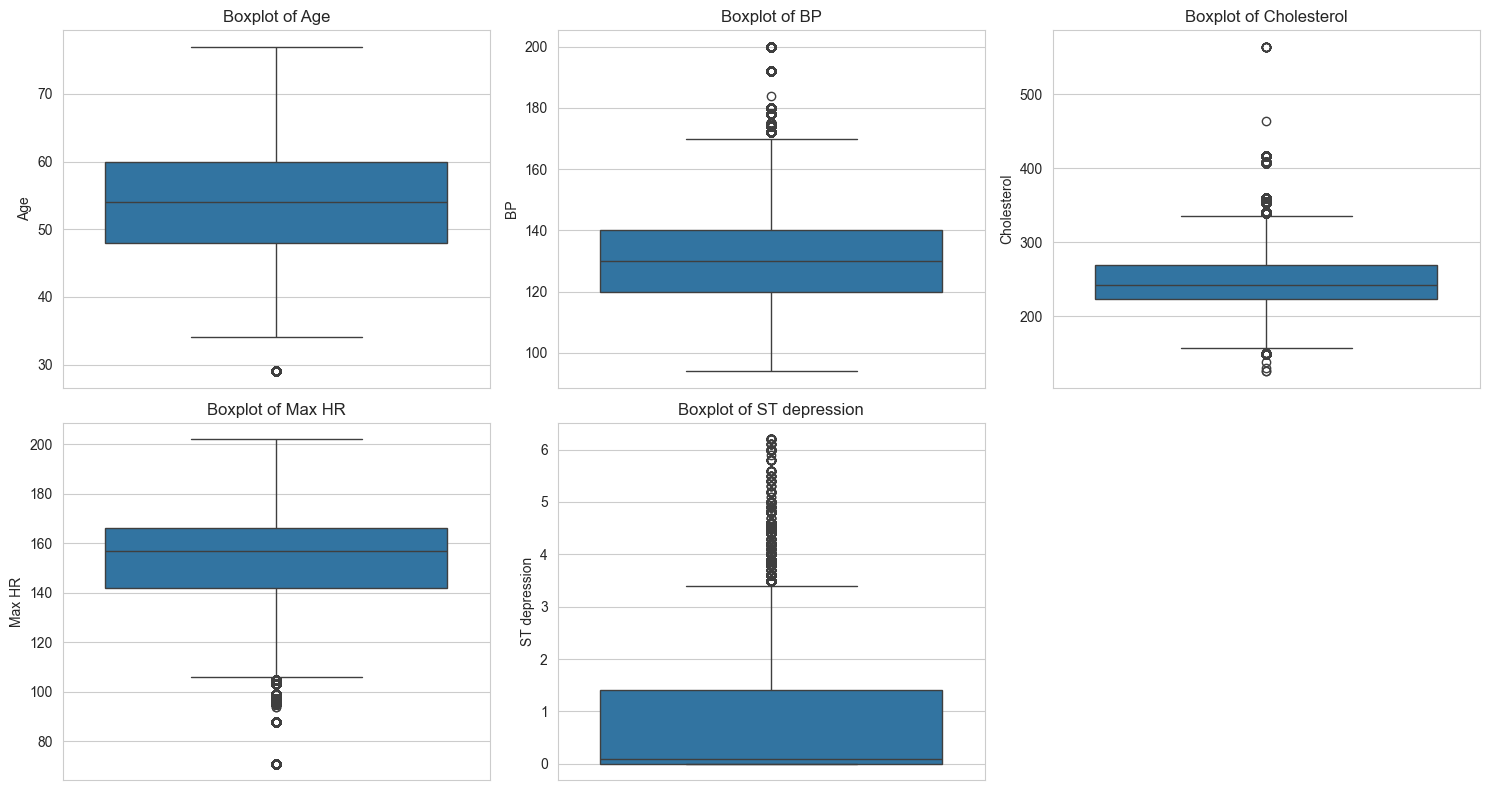

In [18]:
# Plot boxplots for numerical features
n = len(numerical_features)
cols = 3
rows = (n + cols - 1) // cols
plt.figure(figsize=(5*cols, 4*rows))
for i, col in enumerate(numerical_features):
    ax = plt.subplot(rows, cols, i + 1)
    sns.boxplot(y=heart_data[col].dropna(), ax=ax)
    ax.set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

## 6. Assess target variable distribution

In [19]:
# Count of each class in the target variable
target_counts = heart_data['Heart Disease'].value_counts()
print("\nValue Counts for Target Variable 'Heart Disease':")
print(target_counts)


Value Counts for Target Variable 'Heart Disease':
Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64


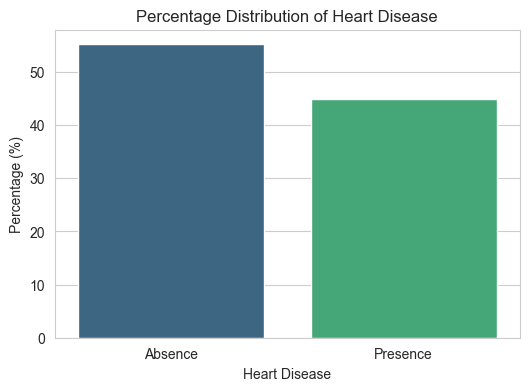

In [20]:
# Plot the percentage distribution of the target variable
target_counts_percent = target_counts / target_counts.sum() * 100
plt.figure(figsize=(6, 4))
sns.barplot(x=target_counts_percent.index, y=target_counts_percent.values, palette='viridis')
plt.title('Percentage Distribution of Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.show()

### 💡 Insight:
- The target variable is relatively balanced, with a slight majority of patients not having heart disease. This balance is beneficial for modeling, as it reduces the risk of bias towards the majority class.

## 7. Univariate analysis

### 7.1. Numeric features

In [21]:
# Define a function to plot KDE for numerical features by target variable
def plot_kde(data, feature, target='Heart Disease'):
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=data, x=feature, hue=target, fill=True, palette='viridis')
    plt.title(f'KDE Plot of {feature} by {target}')
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.show()

In [22]:
# Define a function to plot boxplots for numerical features by target variable
def plot_box(data, feature, target='Heart Disease'):
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=target, y=feature, data=data, palette='viridis')
    plt.title(f'Boxplot of {feature} by {target}')
    plt.xlabel(target)
    plt.ylabel(feature)
    plt.show()

In [23]:
# Define a function to count outliers in numerical features by target variable
# It first identifies outliers using the IQR method and then counts how many outliers correspond to each class in the target variable.
def count_outliers(data, feature, target='Heart Disease'):
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
    outlier_counts = outliers[target].value_counts()
    return outlier_counts

In [24]:
# Define a function to plot a QQ plot for numerical features by target variable
def plot_qq(data, feature, target='Heart Disease'):
    categories = data[target].unique()
    plt.figure(figsize=(12, 5))
    for i, category in enumerate(categories):
        subset = data[data[target] == category][feature].dropna()
        plt.subplot(1, len(categories), i + 1)
        stats.probplot(subset, dist="norm", plot=plt)
        plt.title(f'QQ Plot of {feature} for {target}={category}')
    plt.tight_layout()
    plt.show()

In [25]:
# Define a function that runs all the above functions and prints the results
def analyze_numerical_feature(data, feature, target='Heart Disease'):
    print("=" * 50)
    print(f"\nAnalyzing Numerical Feature: {feature}\n")
    
    # Plot KDE
    plot_kde(data, feature, target)
    
    # Plot Boxplot
    plot_box(data, feature, target)
    
    # Count Outliers
    outlier_counts = count_outliers(data, feature, target)
    print(f"Outlier Counts for {feature} by {target}:")
    print(outlier_counts)
    
    # Plot QQ Plot
    plot_qq(data, feature, target)


Analyzing Numerical Feature: Age



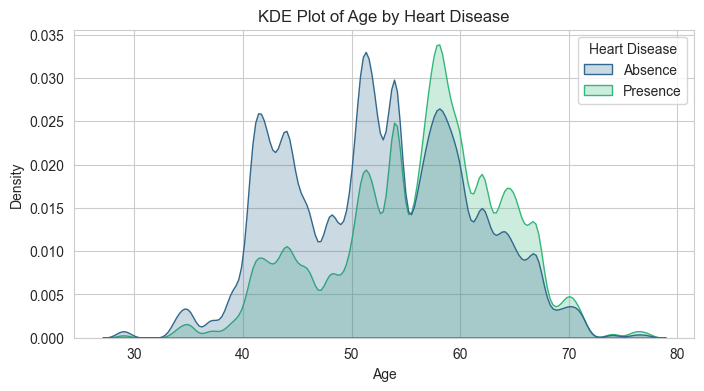

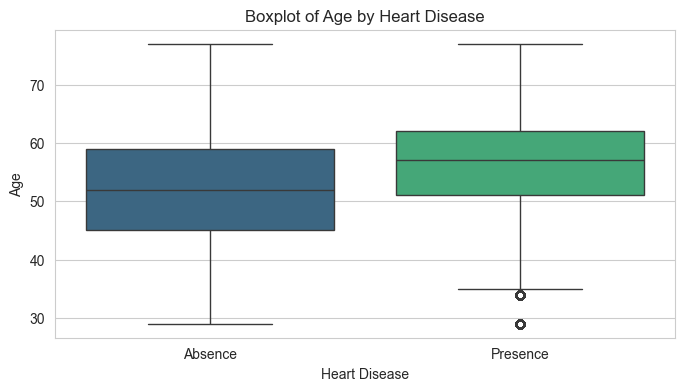

Outlier Counts for Age by Heart Disease:
Heart Disease
Absence     774
Presence    274
Name: count, dtype: int64


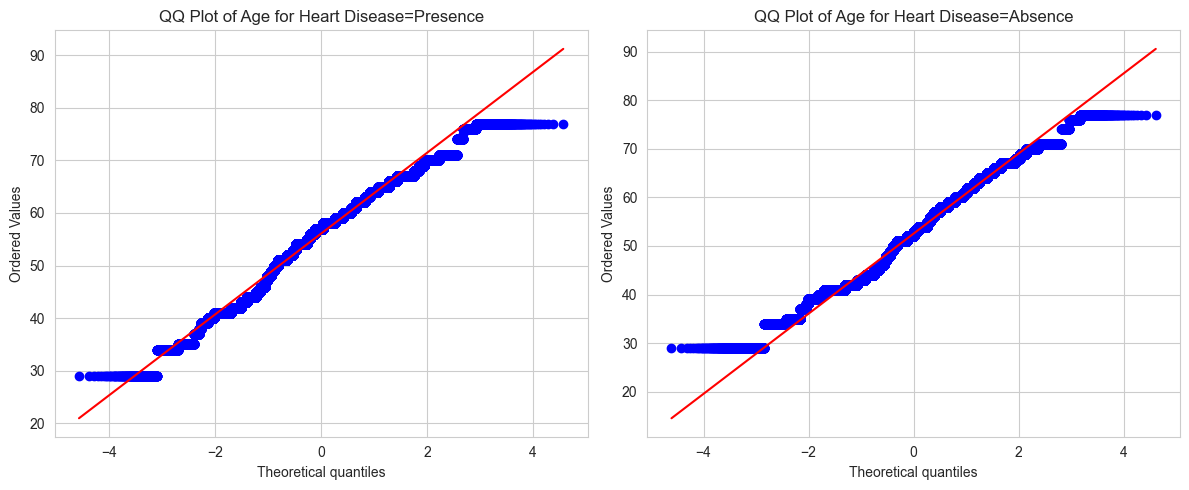


Analyzing Numerical Feature: BP



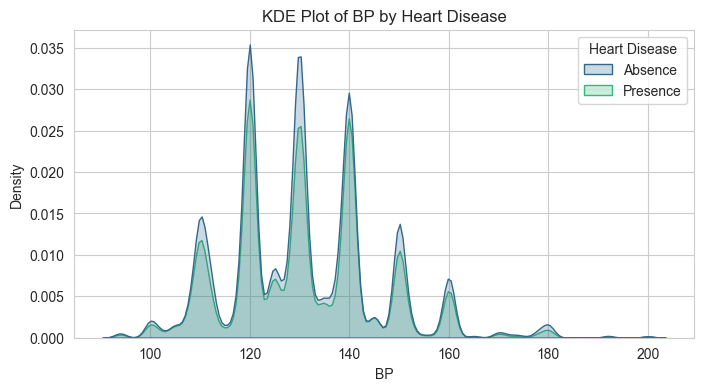

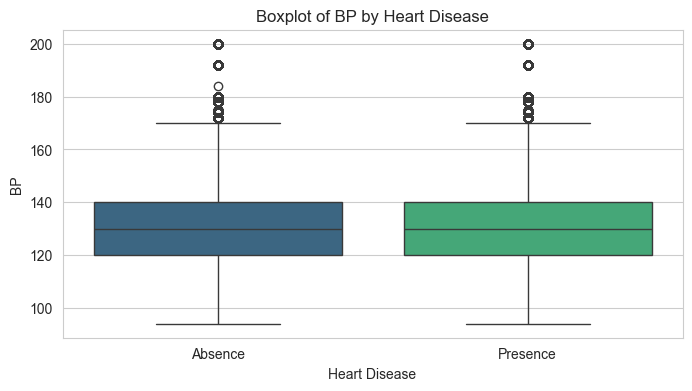

Outlier Counts for BP by Heart Disease:
Heart Disease
Absence     5643
Presence    3368
Name: count, dtype: int64


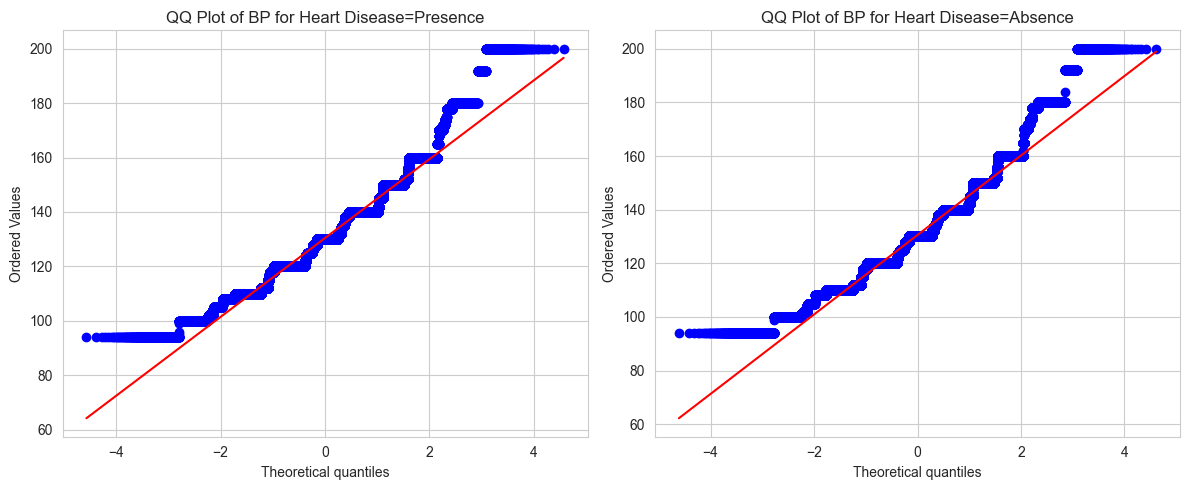


Analyzing Numerical Feature: Cholesterol



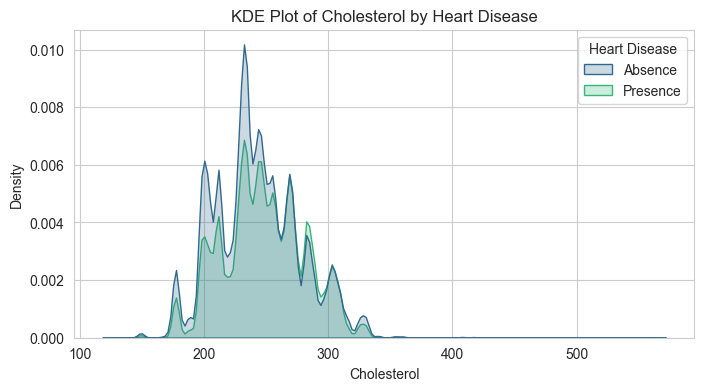

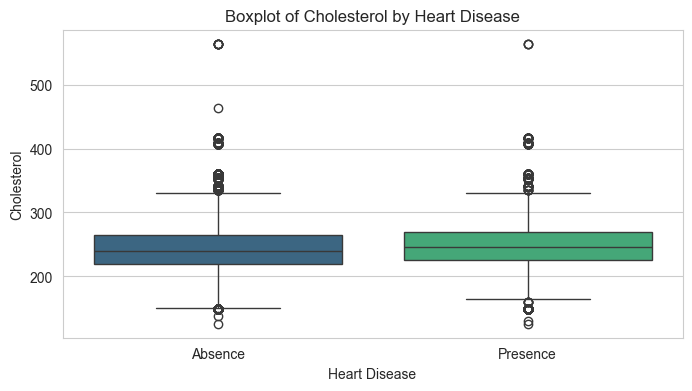

Outlier Counts for Cholesterol by Heart Disease:
Heart Disease
Absence     1552
Presence     642
Name: count, dtype: int64


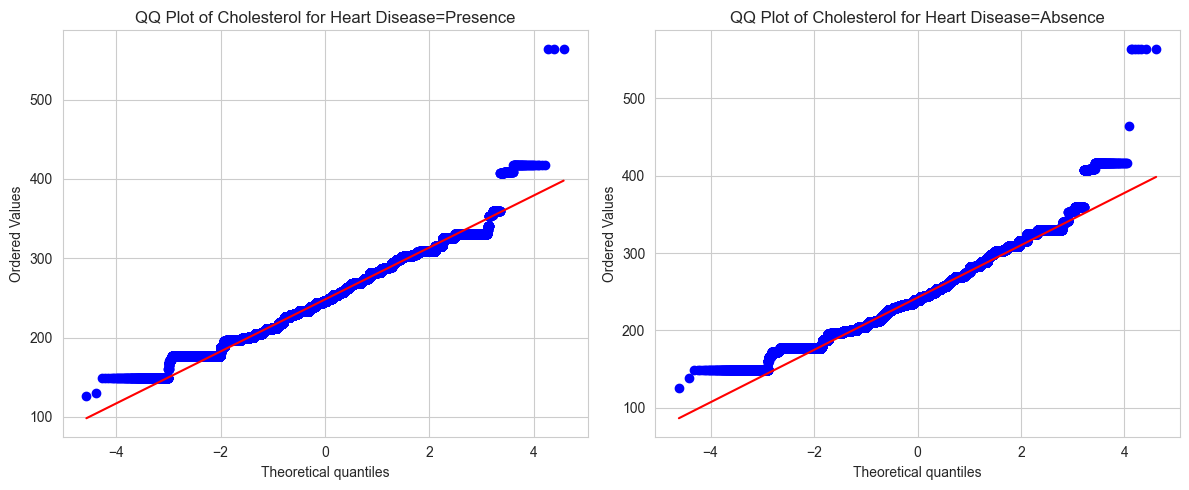


Analyzing Numerical Feature: Max HR



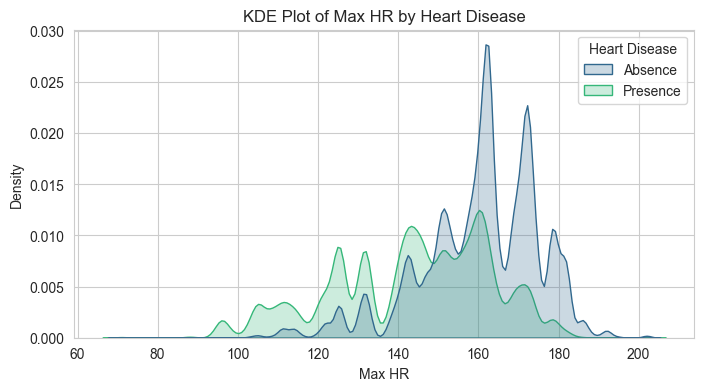

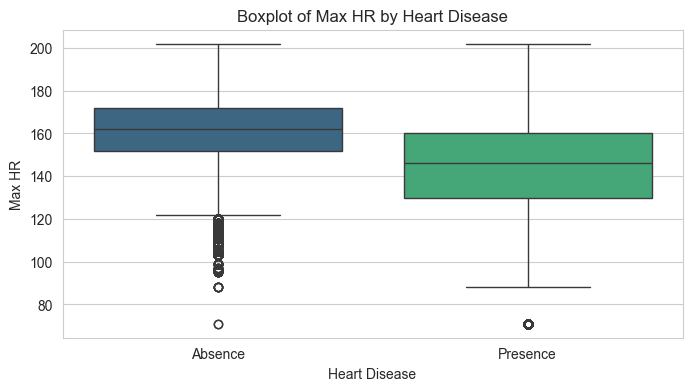

Outlier Counts for Max HR by Heart Disease:
Heart Disease
Presence    13573
Absence       673
Name: count, dtype: int64


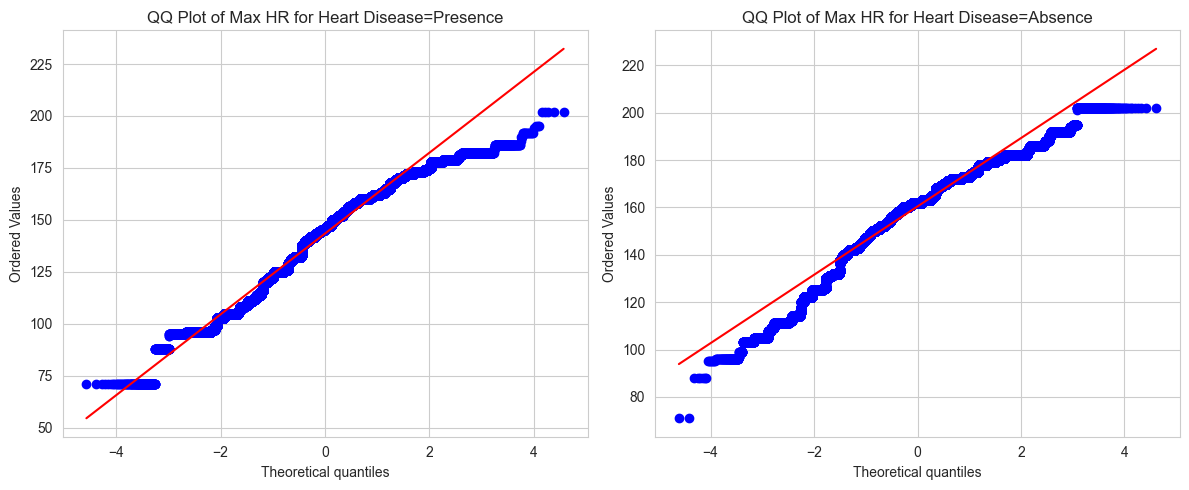


Analyzing Numerical Feature: ST depression



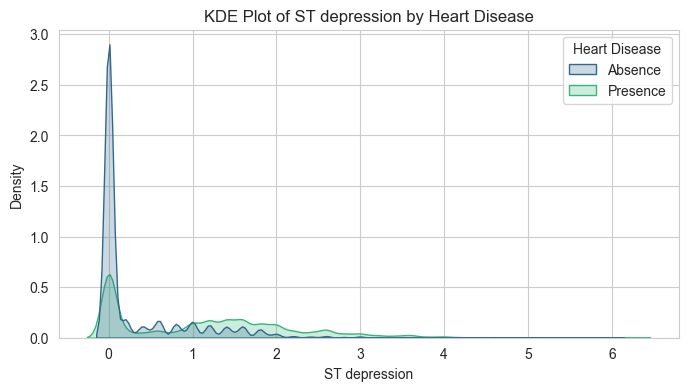

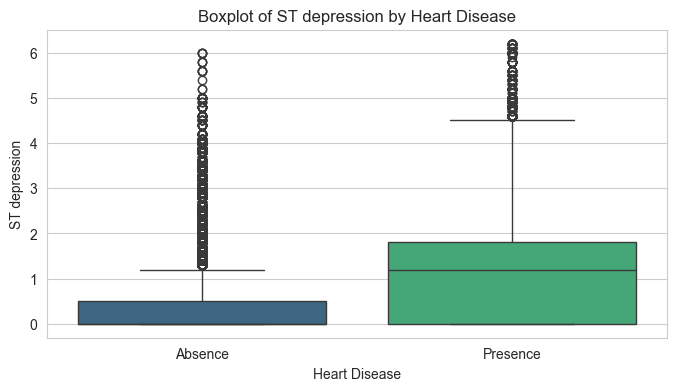

Outlier Counts for ST depression by Heart Disease:
Heart Disease
Presence    9063
Absence      908
Name: count, dtype: int64


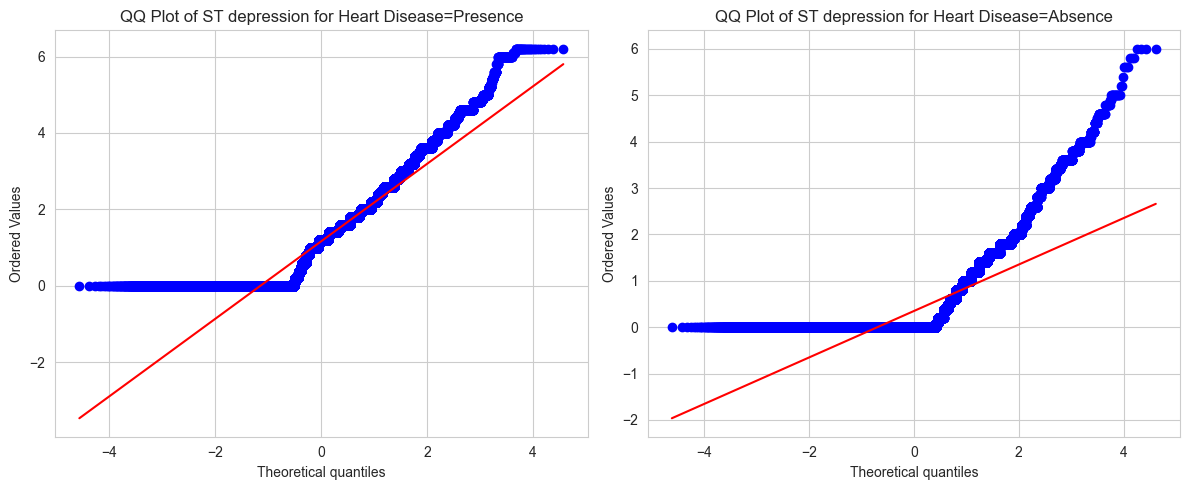

In [26]:
# Analyze each numerical feature
for feature in numerical_features:
    analyze_numerical_feature(heart_data, feature)

### 💡 Insight:
**Key findings**:
- Most numerical features deviate from normality based on QQ plots, which is common in clinical data and justifies the use of non-parametric tests such as Mann-Whitney U.
- Blood pressure alone does not show a meaningful univariate difference between groups, suggesting it may not be a strong standalone predictor. However, it may still contribute in interaction with other clinical variables.
- Some of the features (such as ST depression and Age) have significantly more outliers depending on the class of our target variable.

### 7.2 Categorical features

In [27]:
# Define a function to plot the distribution of a categorical feature by target variable
def plot_categorical_distribution(data, feature, target='Heart Disease'):
    print("=" * 50)
    print(f"\nAnalyzing Categorical Feature: {feature}\n")

    subset = data[[feature, target]].dropna()
    grouped = subset.groupby([feature, target]).size().reset_index(name='count')
    grouped['percentage'] = grouped.groupby(feature)['count'].transform(lambda x: x / x.sum() * 100)
    
    plt.figure(figsize=(8, 4))
    sns.barplot(x=feature, y='percentage', hue=target, data=grouped, palette='viridis')
    plt.title(f'Distribution of {feature} by {target}')
    plt.xlabel(feature)
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=0)
    plt.legend(title=target)
    plt.show()

    crosstab = pd.crosstab(data[feature], data[target])
    print(f"Contingency Table for {feature} and {target}:")
    print(crosstab)


Analyzing Categorical Feature: Sex



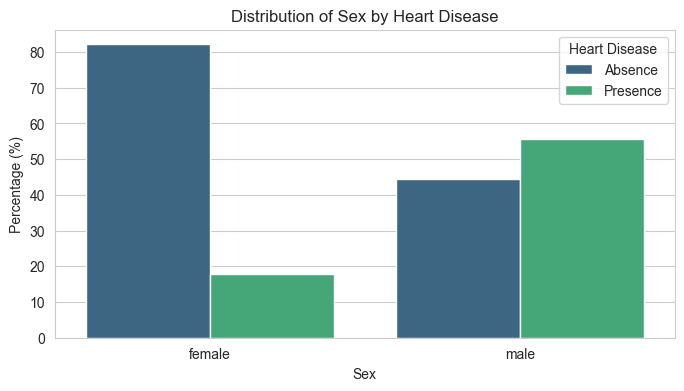

Contingency Table for Sex and Heart Disease:
Heart Disease  Absence  Presence
Sex                             
female          147590     32127
male            199956    250327

Analyzing Categorical Feature: Chest pain type



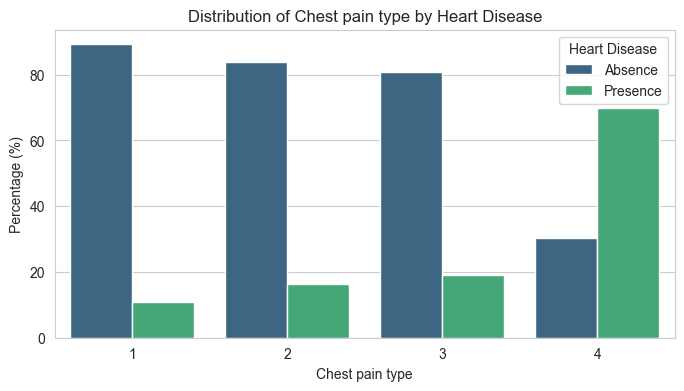

Contingency Table for Chest pain type and Heart Disease:
Heart Disease    Absence  Presence
Chest pain type                   
1                  25511      3091
2                  62787     12154
3                 159664     37614
4                  99584    229595

Analyzing Categorical Feature: FBS over 120



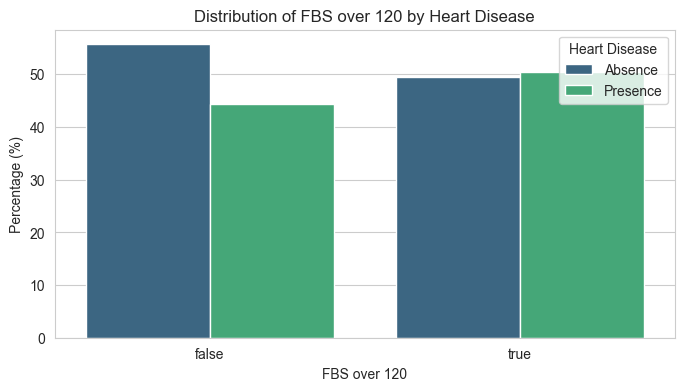

Contingency Table for FBS over 120 and Heart Disease:
Heart Disease  Absence  Presence
FBS over 120                    
false           322600    257008
true             24946     25446

Analyzing Categorical Feature: EKG results



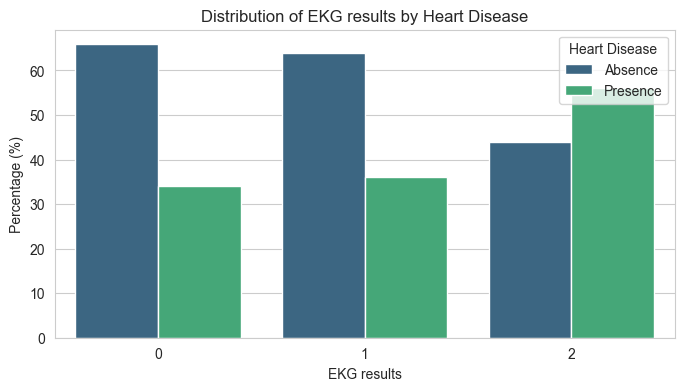

Contingency Table for EKG results and Heart Disease:
Heart Disease  Absence  Presence
EKG results                     
0               210797    109319
1                  846       476
2               135903    172659

Analyzing Categorical Feature: Exercise angina



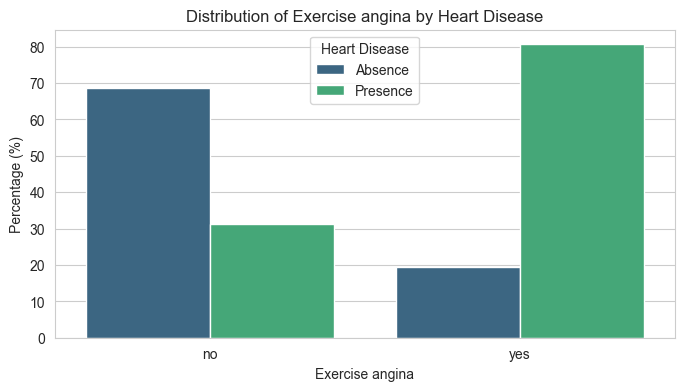

Contingency Table for Exercise angina and Heart Disease:
Heart Disease    Absence  Presence
Exercise angina                   
no                314141    143412
yes                33405    139042

Analyzing Categorical Feature: Slope of ST



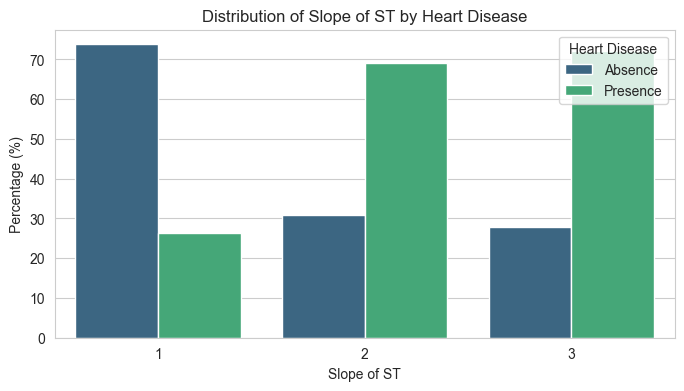

Contingency Table for Slope of ST and Heart Disease:
Heart Disease  Absence  Presence
Slope of ST                     
1               264328     93965
2                78897    177318
3                 4321     11171

Analyzing Categorical Feature: Number of vessels fluro



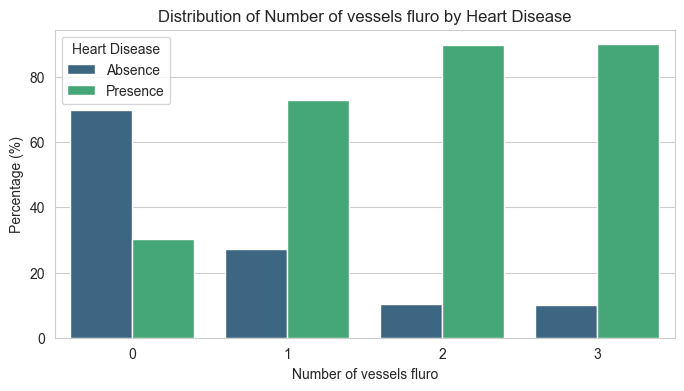

Contingency Table for Number of vessels fluro and Heart Disease:
Heart Disease            Absence  Presence
Number of vessels fluro                   
0                         310707    135155
1                          28954     78024
2                           5589     48714
3                           2296     20561

Analyzing Categorical Feature: Thallium



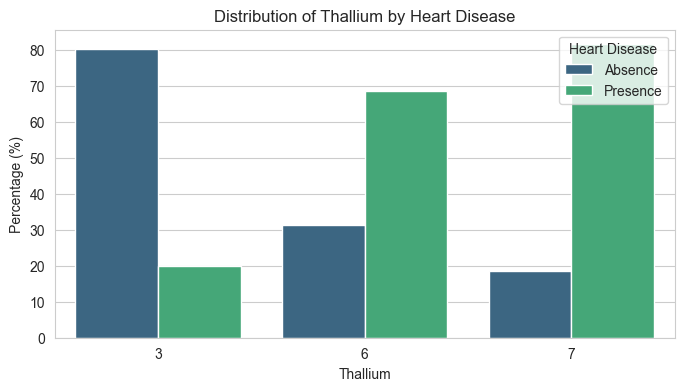

Contingency Table for Thallium and Heart Disease:
Heart Disease  Absence  Presence
Thallium                        
3               298555     73731
6                 3439      7527
7                45552    201196


In [28]:
# Analyze each categorical feature
for feature in categorical_features:
    plot_categorical_distribution(heart_data, feature, target='Heart Disease')

### 💡 Insight:
- Based on the evaluation of our categorical features, certain factors seem to significantly increase the likelihood of heart disease being present, such as:
    - Sex = male
    - Asymptomatic chest pain (cp = 4)
- These patterns suggest strong associations that warrant further investigation.

## 8. Bivariate analysis

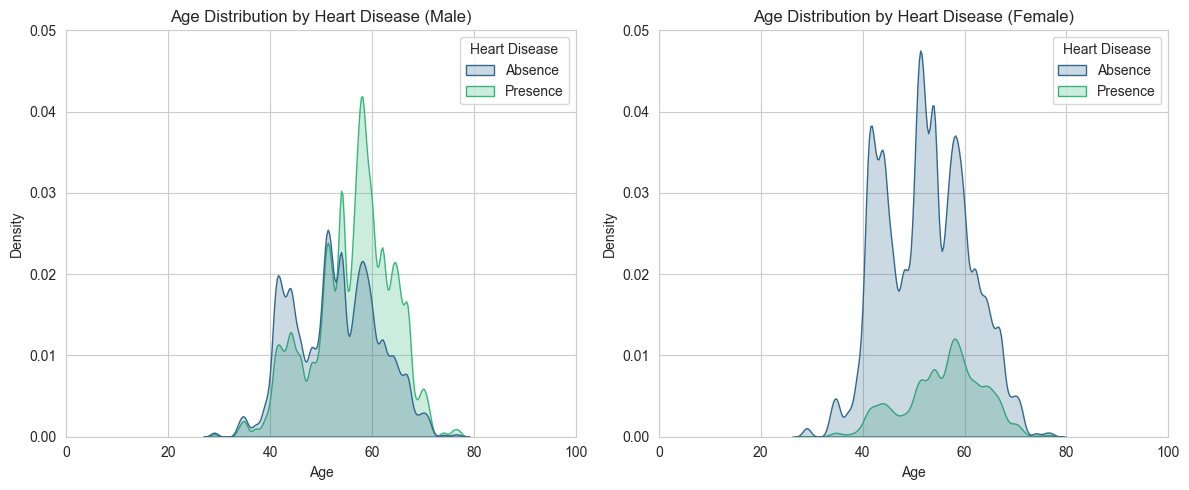

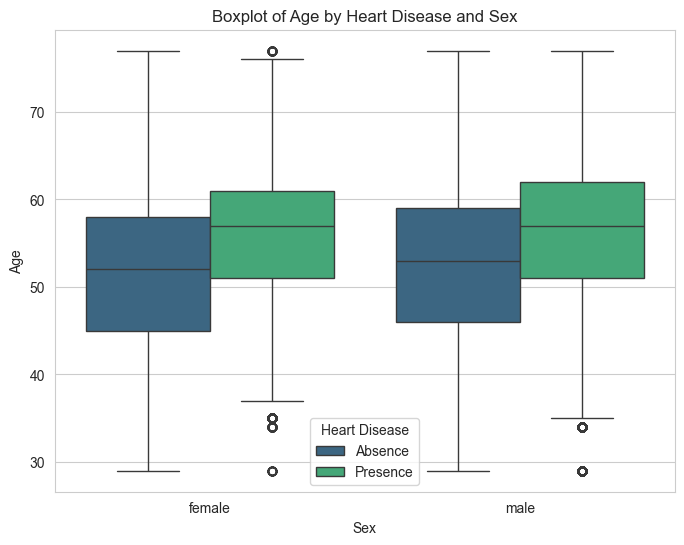

In [29]:
# Plotting age distribution by heart disease and sex
male = heart_data[heart_data['Sex'] == 'male']
female = heart_data[heart_data['Sex'] == 'female']

# KDE plots for age distribution by heart disease and sex
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Male subplot
sns.kdeplot(
    data=male,
    x='Age',
    hue='Heart Disease',
    fill=True,
    palette='viridis',
    ax=axes[0]
)
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 0.05)
axes[0].set_title('Age Distribution by Heart Disease (Male)')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Density')
axes[0].get_legend().set_title('Heart Disease')

# Female subplot
sns.kdeplot(
    data=female,
    x='Age',
    hue='Heart Disease',
    fill=True,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_xlim(0, 100)
axes[1].set_ylim(0, 0.05)
axes[1].set_title('Age Distribution by Heart Disease (Female)')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')
axes[1].get_legend().set_title('Heart Disease')

plt.tight_layout()
plt.show()

# Boxplot of age by heart disease and sex
plt.figure(figsize=(8, 6))
sns.boxplot(x='Sex', y='Age', hue='Heart Disease', data=heart_data, palette='viridis')
plt.title('Boxplot of Age by Heart Disease and Sex')
plt.xlabel('Sex')
plt.ylabel('Age')
plt.legend(title='Heart Disease')
plt.show()

### 💡 Insight:
- The distribution analysis indicates that age is positively associated with heart disease in both sexes, with a more pronounced age shift among females. However, the significant overlap between distributions suggests that age alone is insufficient as a discriminative feature and should be analyzed jointly with other clinical variables.

### 8.3. Correlation analysis

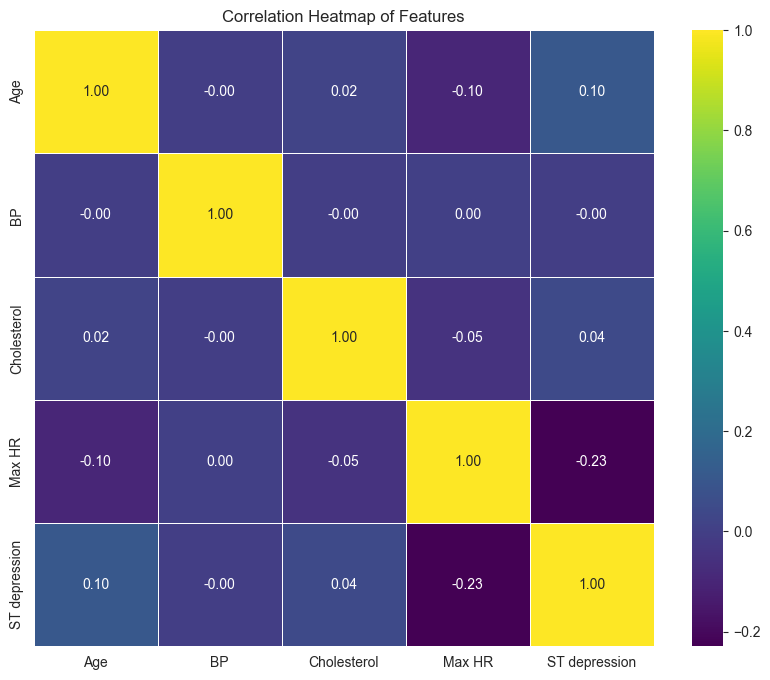

In [30]:
# Plotting a heatmap of correlations between numerical features
plt.figure(figsize=(10, 8))
correlations = heart_data[numerical_features].corr()
sns.heatmap(correlations, annot=True, cmap='viridis', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Features')
plt.show()

### 💡 Insight:
- There doesn't seem to be a strong correlation between any of the numeric features. This is a good sign as it suggests that our features are not redundant and may provide unique information to our model.
- The highest correlation is between "ST depression" and "Max HR".

## 9. Hypothesis testing

### 9.1. Numeric features

- Given the large sample size (630k), statistical tests are expected to yield extremely small p-values even for small effect sizes. Therefore, effect sizes (Cramér’s V, rank-biserial) are emphasized over p-values

In [31]:
# Define a function to calculate the rank biserial effect size for a Mann-Whitney U test
def rank_biserial_u(x, y, U):
    n1 = len(x)
    n2 = len(y)
    return 1 - (2 * U) / (n1 * n2)

In [32]:
# Define a function to perform Mann-Whitney U test and calculate effect size for a numerical feature by target variable
# also calculates descriptive statistics for each group (presence and absence of heart disease) and returns a dictionary with all the results.
def evaluate_numerical_feature(data, feature):
    G1 = data[data['Heart Disease'] == 'Presence'][feature].dropna()
    G2 = data[data['Heart Disease'] == 'Absence'][feature].dropna()
    stat, p_value = stats.mannwhitneyu(G1, G2, alternative='two-sided')
    effect_size = rank_biserial_u(G1, G2, stat)
    return {
        'feature': feature,
        'n_presence': len(G1),
        'n_absence': len(G2),
        'mean_presence': G1.mean(),
        'mean_absence': G2.mean(),
        'median_presence': G1.median(),
        'median_absence': G2.median(),
        'std_presence': G1.std(),
        'std_absence': G2.std(),
        'iqr_presence': G1.quantile(0.75) - G1.quantile(0.25),
        'iqr_absence': G2.quantile(0.75) - G2.quantile(0.25),
        'U_statistic': stat,
        'p_value': p_value,
        'effect_size': effect_size
    }

In [33]:
# Evaluate each numerical feature and store results in a list of dictionaries
results_num = []
for feature in numerical_features:
    result = evaluate_numerical_feature(heart_data, feature)
    results_num.append(result)

results_num_df = pd.DataFrame(results_num)

In [34]:
# Apply FDR correction to p-values and add corrected p-values and rejection decisions to the results DataFrame
rej, pvals_corrected, _, _ = multipletests(results_num_df['p_value'], method='fdr_bh')
results_num_df['p_value_corrected'] = pvals_corrected
results_num_df['reject_null'] = rej

results_num_df = results_num_df.sort_values('p_value_corrected')
results_num_df

,feature,n_presence,n_absence,mean_presence,mean_absence,median_presence,median_absence,std_presence,std_absence,iqr_presence,iqr_absence,U_statistic,p_value,effect_size,p_value_corrected,reject_null
0,Age,282454,347546,56.079114,52.558093,57.0,52.0,7.768723,8.304120,11.0,14.0,6.141781e+10,0.000000,-0.251308,0.000000,True
2,Cholesterol,282454,347546,248.103585,242.499102,246.0,239.0,32.922645,34.080064,43.0,46.0,5.427624e+10,0.000000,-0.105808,0.000000,True
3,Max HR,282454,347546,143.467372,160.415105,146.0,162.0,19.722854,14.740398,30.0,20.0,2.396147e+10,0.000000,0.511816,0.000000,True
4,ST depression,282454,347546,1.169104,0.347808,1.2,0.0,1.066893,0.634996,1.8,0.5,7.202202e+10,0.000000,-0.467355,0.000000,True
1,BP,282454,347546,130.411366,130.567381,130.0,130.0,14.776321,15.135647,20.0,20.0,4.913056e+10,0.503108,-0.000972,0.503108,False


### 💡 Insight:
- Blood pressure does not show a significant difference between patients with and without heart disease, suggesting that it may not be a strong standalone predictor in this dataset. However, it may still contribute to predictive models when combined with other features.
- Max heart rate, ST depression, and age all show significant differences between the two groups, indicating they may be important features for predicting heart disease.

### 9.2. Categorical features

In [35]:
# Define a function to perform chi-square test for a categorical feature by target variable
def evaluate_categorical_feature(data, feature, target='Heart Disease'):
    contingency_table = pd.crosstab(data[feature], data[target])

    chi2, p_value, _, _ = stats.chi2_contingency(contingency_table)

    # Calculate Cramér's V for effect size
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))

    v_significance = ''
    if cramers_v < 0.1:
        v_significance = 'Negligible'
    elif cramers_v < 0.3:
        v_significance = 'Weak'
    elif cramers_v < 0.5:
        v_significance = 'Moderate'
    elif cramers_v < 0.7:
        v_significance = 'Strong'

    return {
        'feature': feature,
        'chi2_statistic': chi2,
        'p_value': p_value,
        'effect_size': cramers_v,
        'effect_size_significance': v_significance
    }

In [36]:
# Evaluate each categorical feature and store results in a list of dictionaries
results_cat = []
for feature in categorical_features:
    result = evaluate_categorical_feature(heart_data, feature)
    results_cat.append(result)

results_cat_df = pd.DataFrame(results_cat)

In [37]:
rej, pvals_corrected, _, _ = multipletests(results_cat_df['p_value'], method='fdr_bh')
results_cat_df['p_value_corrected'] = pvals_corrected
results_cat_df['reject_null'] = rej

results_cat_df = results_cat_df.sort_values('p_value_corrected')
results_cat_df

,feature,chi2_statistic,p_value,effect_size,effect_size_significance,p_value_corrected,reject_null
0,Sex,73878.222487,0.000000e+00,0.342443,Moderate,0.000000e+00,True
1,Chest pain type,173770.661665,0.000000e+00,0.525192,Strong,0.000000e+00,True
3,EKG results,30248.416205,0.000000e+00,0.219120,Weak,0.000000e+00,True
4,Exercise angina,123001.448331,0.000000e+00,0.441860,Moderate,0.000000e+00,True
6,Number of vessels fluro,135190.518244,0.000000e+00,0.463237,Moderate,0.000000e+00,True
5,Slope of ST,116357.579387,0.000000e+00,0.429761,Moderate,0.000000e+00,True
7,Thallium,231215.691767,0.000000e+00,0.605813,Strong,0.000000e+00,True
2,FBS over 120,709.738192,2.280820e-156,0.033564,Negligible,2.280820e-156,True


### 💡 Insight:
- All categorical features show significant associations with heart disease.
- Thallium and chest pain type have the strongest associations, suggesting they may be particularly important for predicting heart disease in this dataset.

## 10. Baseline Modeling (Sanity Check)

To complement the EDA, a simple baseline model is trained to verify whether the observed statistical patterns translate into predictive signal.
This model is not intended for optimization, but rather as a sanity check to assess feature informativeness.
A more rigorous modeling pipeline (cross-validation, tuning, and explainability) will be developed in a separate notebook.

In [38]:
# Prepare data for modeling by separating features and target variable
X = heart_data.drop(columns=['id', 'Heart Disease'])
y = heart_data['Heart Disease'].map({'Presence': 1, 'Absence': 0})

In [39]:
# Encode categorical features using one-hot encoding
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded.head()

,Age,BP,Cholesterol,Max HR,ST depression,Sex_male,Chest pain type_2,Chest pain type_3,Chest pain type_4,FBS over 120_true,EKG results_1,EKG results_2,Exercise angina_yes,Slope of ST_2,Slope of ST_3,Number of vessels fluro_1,Number of vessels fluro_2,Number of vessels fluro_3,Thallium_6,Thallium_7
0,58,152,239,158,3.6,True,False,False,True,False,False,False,True,True,False,False,True,False,False,True
1,52,125,325,171,0.0,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False
2,56,160,188,151,0.0,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False
3,44,134,229,150,1.0,False,False,True,False,False,False,True,False,True,False,False,False,False,False,False
4,58,140,234,125,3.8,True,False,False,True,False,False,True,True,True,False,False,False,True,False,False


In [40]:
# Split the data into training and testing sets with stratification to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 504000 samples
Testing set size: 126000 samples


In [41]:
# Train a Random Forest Classifier on the training data
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [42]:
# Get predicted probabilities for the positive class (presence of heart disease) for both training and testing sets
y_proba_train = rf_model.predict_proba(X_train)[:, 1]
y_proba_test = rf_model.predict_proba(X_test)[:, 1]

In [43]:
# Calculate AUC-ROC for both training and testing sets to evaluate model performance
auc_train = roc_auc_score(y_train, y_proba_train)
auc_test = roc_auc_score(y_test, y_proba_test)

print(f"AUC-ROC for Training Set: {auc_train:.4f}")
print(f"AUC-ROC for Testing Set: {auc_test:.4f}")

AUC-ROC for Training Set: 1.0000
AUC-ROC for Testing Set: 0.9471


### 💡 Insight:
- The perfect training AUC (1.00) suggests potential overfitting, which is expected given the model complexity and large synthetic dataset. Cross-validation and hyperparameter tuning will be explored in the dedicated modeling notebook to better assess generalization.

In [44]:
# Assessing feature importance on the trained Random Forest model
feature_importances = rf_model.feature_importances_
feature_names = X_encoded.columns
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

feature_importance_df.head(10)

,feature,importance
19,Thallium_7,0.193395
3,Max HR,0.136916
8,Chest pain type_4,0.104964
4,ST depression,0.087815
2,Cholesterol,0.087709
0,Age,0.077127
12,Exercise angina_yes,0.069769
1,BP,0.061861
13,Slope of ST_2,0.044652
5,Sex_male,0.032598


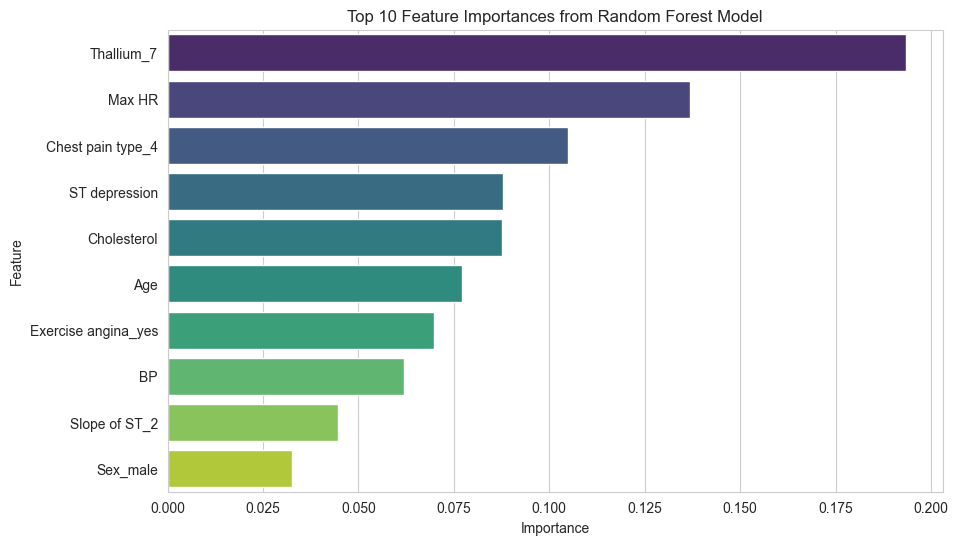

In [45]:
# Plotting the top 10 most important features based on the Random Forest model
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('Top 10 Feature Importances from Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### 💡 Insight:
- Feature importance from the baseline model broadly aligns with earlier statistical findings, particularly highlighting Thallium, Chest Pain Type, and Max HR as influential predictors. However, these importances are model-specific and should be interpreted as exploratory rather than causal.

In [46]:
from sklearn.base import BaseEstimator

def save_fitted_models(namespace, destination, prefix):
    destination.mkdir(parents=True, exist_ok=True)
    saved_files = []
    for name, obj in namespace.items():
        if name.startswith('_'):
            continue
        if not isinstance(obj, BaseEstimator):
            continue
        if not hasattr(obj, 'predict'):
            continue
        try:
            is_fitted = any(attr.endswith('_') and not attr.startswith('__') for attr in vars(obj))
        except TypeError:
            is_fitted = False
        if not is_fitted:
            continue
        model_path = destination / f"{prefix}_{name}.joblib"
        joblib.dump(obj, model_path)
        saved_files.append(model_path.name)
    return saved_files

saved_models = save_fitted_models(globals(), MODELS_DIR, '01_eda')
if saved_models:
    print('Saved models:')
    for model_file in saved_models:
        print(f' - {model_file}')
else:
    print('No fitted models found to save.')

Saved models:
 - 01_eda_rf_model.joblib
